**Simulation**

In [7]:
import os
import subprocess

# Projektname
name = "capacity"

def generateNetwork():

    with open(f"{name}.nod.xml", "w") as f:
        f.write(f"""<nodes>
        <node id="start" x="0" y="0"/>
        <node id="ende" x="1000" y="0"/>
    </nodes>""")

    with open(f"{name}.edg.xml", "w") as f:
        f.write(f"""<edges>
    <edge id="strasse" from="start" to="ende" numLanes="1" speed="13.89"/>
    </edges>""")
        
    with open(f"{name}.add.xml", "w") as f:
        f.write(f"""<additional>
        <edgeData id="messung_stunde" file="{name}_output.xml" freq="3600"/>
    </additional>""")

    subprocess.run(["netconvert", "--node-files", f"{name}.nod.xml", 
                "--edge-files", f"{name}.edg.xml", 
                "-o", f"{name}.net.xml"], check=True)
    
    with open(f"{name}.sumocfg", "w") as f:
        f.write(f"""<configuration>
        <input>
            <net-file value="{name}.net.xml"/>
            <route-files value="{name}.rou.xml"/>
            <additional-files value="{name}.add.xml"/>
        </input>
        <output>
            <summary-output value="{name}_summary.xml"/>
        </output>
        <time>
            <begin value="0"/>
            <end value="3600"/>
        </time>
    </configuration>""")

In [8]:
generateNetwork()

Simuliere Demand: 200...
Simuliere Demand: 500...
Simuliere Demand: 800...
Simuliere Demand: 1100...
Simuliere Demand: 1400...
Simuliere Demand: 1700...
Simuliere Demand: 2000...
Simuliere Demand: 2300...
Simuliere Demand: 2600...
Simuliere Demand: 3000...


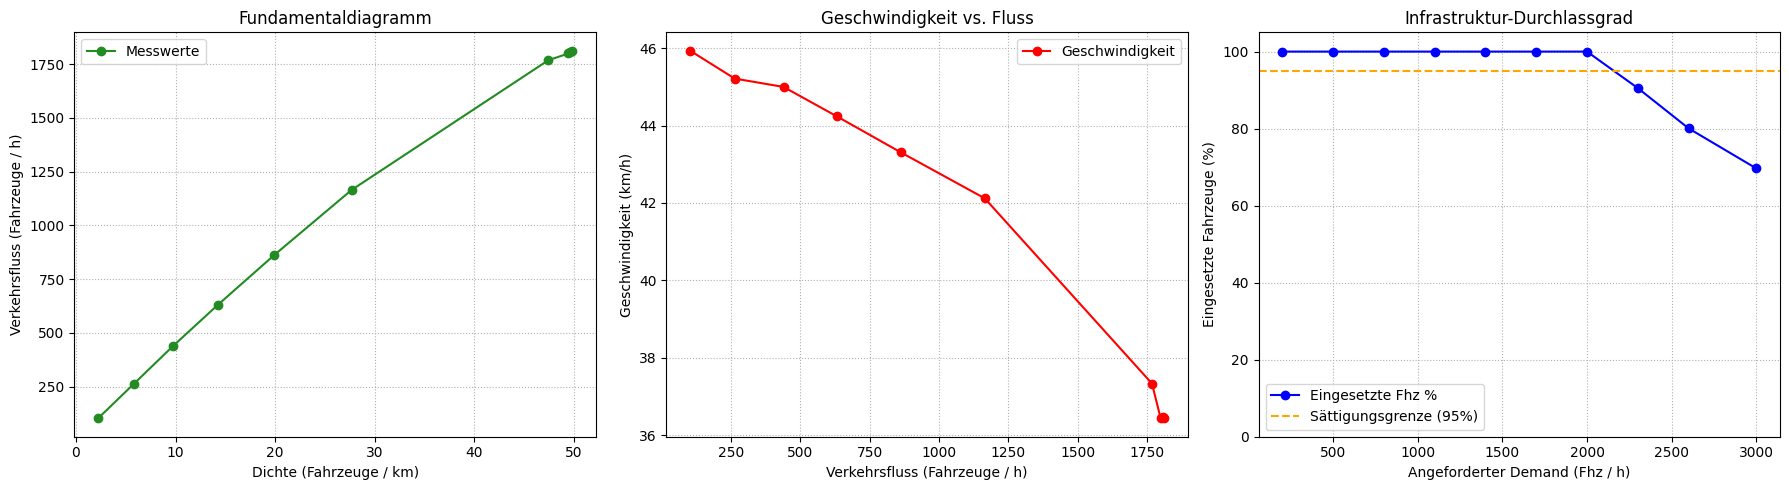

In [11]:
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import subprocess
import os

# Konfiguration
name = "capacity"
demands = [200, 500, 800, 1100, 1400, 1700, 2000, 2300, 2600, 3000]
results = []

def run_sim(demand):
    # 1. Route Datei schreiben (mit optimierten Einfahr-Parametern)
    with open(f"{name}.rou.xml", "w") as f:
        f.write(f"""<routes>
    <vType id="pkw" accel="2.6" decel="4.5" sigma="0.5" length="5" minGap="2.5" maxSpeed="13.89"/>
    <flow id="f1" type="pkw" begin="0" end="3600" vehsPerHour="{demand}" 
          from="strasse" to="strasse" departSpeed="max" departLane="best" departPos="random_free"/>
</routes>""")
    
    # 2. Simulation ausführen
    subprocess.run(["sumo", "-c", f"{name}.sumocfg", "--no-warnings"], check=True)

    # 3. Summary-Datei parsen für Efficiency
    tree_sum = ET.parse(f"{name}_summary.xml")
    root_sum = tree_sum.getroot()
    last_step = root_sum.findall("step")[-1]
    
    loaded = float(last_step.get("loaded"))
    inserted = float(last_step.get("inserted"))
    efficiency = (inserted / loaded) * 100 if loaded > 0 else 100
  
    # 4. Output auslesen für Verkehrsfluss-Daten
    tree_out = ET.parse(f"{name}_output.xml")
    root_out = tree_out.getroot()
    edge = root_out.find(".//edge[@id='strasse']")
    
    # Sicherstellen, dass Daten vorhanden sind (falls kein Auto einfuhr)
    flow = float(edge.get("flow")) if edge is not None else 0
    density = float(edge.get("density")) if edge is not None else 0
    speed = float(edge.get("speed")) if edge is not None else 0
    
    return {
        "demand": demand,
        "flow": flow,
        "density": density,
        "efficiency": efficiency,
        "speed": speed * 3.6 # in km/h
    }

# Simulationen starten
for d in demands:
    print(f"Simuliere Demand: {d}...")
    results.append(run_sim(d))

# Daten für Plots extrahieren
d_vals = [r['demand'] for r in results]
densities = [r['density'] for r in results]
flows = [r['flow'] for r in results]
speeds = [r['speed'] for r in results]
effs = [r['efficiency'] for r in results]

# --- Visualisierung (1 Zeile, 3 Spalten) ---
plt.figure(figsize=(18, 5))

# Plot 1: Fundamentaldiagramm (Flow vs Density)
plt.subplot(1, 3, 1)
plt.plot(densities, flows, 'o-', color='forestgreen', label='Messwerte')
plt.xlabel("Dichte (Fahrzeuge / km)")
plt.ylabel("Verkehrsfluss (Fahrzeuge / h)")
plt.title("Fundamentaldiagramm")
plt.grid(True, linestyle=':')
plt.legend()

# Plot 2: Speed vs Flow (Qualität des Verkehrsflusses)
plt.subplot(1, 3, 2)
plt.plot(flows, speeds, 'o-r', label='Geschwindigkeit')
plt.xlabel("Verkehrsfluss (Fahrzeuge / h)")
plt.ylabel("Geschwindigkeit (km/h)")
plt.title("Geschwindigkeit vs. Fluss")
plt.grid(True, linestyle=':')
plt.legend()

# Plot 3: Durchlassgrad (Efficiency vs Demand)
plt.subplot(1, 3, 3)
plt.plot(d_vals, effs, 'o-b', label='Eingesetzte Fhz %')
plt.axhline(y=95, color='orange', linestyle='--', label="Sättigungsgrenze (95%)")
plt.xlabel("Angeforderter Demand (Fhz / h)")
plt.ylabel("Eingesetzte Fahrzeuge (%)")
plt.title("Infrastruktur-Durchlassgrad")
plt.ylim(0, 105)
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()